**ATTENTION AND TRANSFORMERS**

**TRANSFORMER ARCHITECTURE FROM NUMPY**

In [63]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
x = np.random.randn(5,4)
x

array([[-0.89953035,  1.08018208, -0.52892435, -0.63880039],
       [-0.72338705, -2.00064659,  1.20112642, -0.79841263],
       [-1.00949762,  0.8908538 ,  0.16684781,  1.76305877],
       [-1.24062527, -1.18803068,  0.33390353, -0.53794036],
       [ 0.27327127, -0.33596773, -0.72202372, -0.89154367]])

In [65]:
wq = np.random.rand(4,4)
wk = np.random.rand(4,4)
wv = np.random.rand(4,4)

In [66]:
Q = np.dot(x,wq)
K = np.dot(x,wk)
V = np.dot(x,wv)

In [67]:
raw_score = (Q @ K.T)/np.sqrt(4)

In [68]:
raw_score.shape

(5, 5)

In [69]:
softmax = np.exp(raw_score) / np.sum(np.exp(raw_score),axis=1,keepdims=True)

In [70]:
output = np.dot(softmax,V)
output.shape

(5, 4)

In [71]:
print(np.sum(softmax, axis=1))

[1. 1. 1. 1. 1.]


**ATTENTION AND TRANSFORMER APPLIED TO JPMC AND S&P500 DATA**

**PREPARING THE DATA**

In [72]:
jpmc = yf.download(['JPM'],start = '2010-01-1',end='2025-01-01')
sp500 = yf.download(['^GSPC'],start = '2010-01-1',end='2025-01-01')

/tmp/ipykernel_792/4128732890.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpmc = yf.download(['JPM'],start = '2010-01-1',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_792/4128732890.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download(['^GSPC'],start = '2010-01-1',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


**EXPLORATORY DATA ANALYSIS**

In [73]:
jpmc.isnull().sum().sum()

np.int64(0)

In [74]:
sp500.isnull().sum().sum()

np.int64(0)

In [75]:
jpmc.duplicated().sum()

np.int64(0)

In [76]:
sp500.duplicated().sum()

np.int64(0)

In [77]:
jpmc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2010-01-04 to 2024-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   3774 non-null   float64
 1   (High, JPM)    3774 non-null   float64
 2   (Low, JPM)     3774 non-null   float64
 3   (Open, JPM)    3774 non-null   float64
 4   (Volume, JPM)  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [78]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2010-01-04 to 2024-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   3774 non-null   float64
 1   (High, ^GSPC)    3774 non-null   float64
 2   (Low, ^GSPC)     3774 non-null   float64
 3   (Open, ^GSPC)    3774 non-null   float64
 4   (Volume, ^GSPC)  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


**FEATURE ENGINEERING**

In [79]:
#Daily returns
jpmc['returns'] = jpmc['Close']['JPM'].pct_change(fill_method=None)

In [80]:
#volume ratio
volume = jpmc['Volume']['JPM']
jpmc['volume ratio'] = (volume/ volume.rolling(window=20).mean()).shift(1)

In [81]:
#20-day rolling return
jpmc['20-day rolling return'] = jpmc['returns'].rolling(window=20).mean().shift(1)

In [82]:
delta = jpmc['Close']['JPM'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
RSI = 100 - (100 / (1 + gain/loss))
jpmc['RSI'] = RSI.shift(1)

In [83]:
sp500['SP500 returns'] = sp500['Close']['^GSPC'].pct_change(fill_method=None)

In [84]:
sp500_return_dataframe = pd.DataFrame({
    'Date': sp500.index,
    'SP500 returns': sp500['SP500 returns']
})
sp500_return_dataframe.set_index('Date', inplace=True)

In [85]:
jpmc_clean = pd.DataFrame({
    "returns": jpmc['returns'],
    "Volume Ratio": jpmc['volume ratio'],
    "Rolling Returns": jpmc['20-day rolling return'],
    "RSI": jpmc['RSI']
})

In [86]:
jpmc_clean = jpmc_clean.join(sp500_return_dataframe,how='inner')

In [87]:
jpmc_clean['target'] = (jpmc_clean['returns'] > 0).astype(int).shift(-1)

In [88]:
jpmc_clean.dropna(inplace=True)
jpmc_clean

,returns,Volume Ratio,Rolling Returns,RSI,SP500 returns,target
Date,,,,,,
2010-02-03,-0.006411,0.853654,-0.002507,36.611999,-0.005474,0.0
2010-02-04,-0.048151,0.696517,-0.003796,31.106851,-0.031141,0.0
2010-02-05,-0.001304,1.037733,-0.006478,23.539330,0.002897,0.0
2010-02-08,-0.015666,1.327887,-0.007534,25.589922,-0.008863,1.0
2010-02-09,0.018302,1.007097,-0.008194,25.133764,0.013040,1.0
...,...,...,...,...,...,...
2024-12-23,0.003325,3.523394,-0.001417,36.638844,0.007287,1.0
2024-12-24,0.016444,0.934839,-0.002024,39.867619,0.011043,1.0
2024-12-26,0.003425,0.419782,-0.001552,48.407805,-0.000406,0.0


In [89]:
jpmc_clean.shape

(3752, 6)

In [90]:
jpmc_clean.columns

Index(['returns', 'Volume Ratio', 'Rolling Returns', 'RSI', 'SP500 returns',
       'target'],
      dtype='object')

**SEQUENCES AND SPLITTING DATA**

In [91]:
features = jpmc_clean.drop('target',axis=1)
target = jpmc_clean['target']

In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [93]:
target = target.to_numpy()

In [94]:
lookback = 20
x,y = [],[]

for i in range (len(features_scaled) - lookback):
  x.append(features_scaled[i:i+lookback])
  y.append(target[i+lookback])

In [95]:
x = np.array(x)
y = np.array(y)

In [96]:
x.shape

(3732, 20, 5)

In [97]:
y.shape

(3732,)

In [98]:
x_train = x[:int(0.8*len(x))]
y_train = y[:int(0.8*len(y))]
x_test = x[int(0.8*len(x)):]
y_test = y[int(0.8*len(y)):]

In [99]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(2985, 20, 5)
(2985,)
(747, 20, 5)
(747,)


**CREATING TRANSFORMER MODEL**

In [100]:
import torch
import torch.nn as nn

In [101]:
class Transformer(nn.Module):
  def __init__(self,input_size,hidden_size):
    super().__init__()
    self.transformer_layer = nn.TransformerEncoderLayer(d_model = 32,nhead=4,batch_first = True)
    self.transformer = nn.TransformerEncoder(encoder_layer=self.transformer_layer,num_layers=2)
    self.input_proj = nn.Linear(input_size, 32)
    self.fc = nn.Linear(32, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):

    x = self.input_proj(x)
    output=self.transformer(x)
    out = output[:,-1,:]
    out = self.fc(out)
    return self.sigmoid(out)


In [102]:
model = Transformer(5, 32)
print(model)

Transformer(
  (transformer_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
    (linear1): Linear(in_features=32, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=32, bias=True)
    (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2):

**TRAINING DATA PREPARATION**

In [103]:
x_train_t = torch.tensor(x_train,dtype=torch.float32)
y_train_t = torch.tensor(y_train,dtype=torch.float32)
y_train_t = y_train_t.reshape(-1,1)

x_test_t = torch.tensor(x_test,dtype=torch.float32)
y_test_t = torch.tensor(y_test,dtype=torch.float32)
y_test_t = y_test_t.reshape(-1,1)

**MODEL TRAINING AND TESTING (WITHOUT POSITIONAL ENCODING)**

In [104]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [105]:
epochs = 100
batch_size = 32
losses_no_pe = []

for epoch in range(epochs):
    model.train()
    for i in range(0, len(x_train_t), batch_size):
        x_batch = x_train_t[i:i+batch_size]
        y_batch = y_train_t[i:i+batch_size]
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        losses_no_pe.append(loss.item())
    if epoch % 10 == 0:
      print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.7011
Epoch 10, Loss: 0.6972
Epoch 20, Loss: 0.6701
Epoch 30, Loss: 0.6445
Epoch 40, Loss: 0.6750
Epoch 50, Loss: 0.6015
Epoch 60, Loss: 0.4909
Epoch 70, Loss: 0.4351
Epoch 80, Loss: 0.4475
Epoch 90, Loss: 0.3962


In [106]:
print(len(losses_no_pe))

9400


In [107]:
model.eval()

with torch.no_grad():
  y_pred_train = model(x_train_t)
  y_pred_train_class = (y_pred_train > 0.5).float()
  train_accuracy = (y_pred_train_class == y_train_t).float().mean()
  print(f'Train Accuracy: {train_accuracy.item():.4f}')

Train Accuracy: 0.8529


In [108]:
model.eval()

with torch.no_grad():
  y_pred_test = model(x_test_t)
  y_pred_test_class = (y_pred_test > 0.5).float()
  test_accuracy = (y_pred_test_class == y_test_t).float().mean()
  print(f'Train Accuracy: {test_accuracy.item():.4f}')

Train Accuracy: 0.5422


**MODEL TRAINING AND TESTING (WITH POSITIONAL ENCODING)**

In [109]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [110]:
class Transformer(nn.Module):
  def __init__(self,input_size,hidden_size):
    super().__init__()
    self.transformer_layer = nn.TransformerEncoderLayer(d_model = 32,nhead=4,batch_first = True)
    self.transformer = nn.TransformerEncoder(encoder_layer=self.transformer_layer,num_layers=2)
    self.input_proj = nn.Linear(input_size, 32)
    self.fc = nn.Linear(32, 1)
    self.sigmoid = nn.Sigmoid()
    self.pos_encoding = PositionalEncoding(32)

  def forward(self,x):

    x = self.input_proj(x)
    x = self.pos_encoding(x)
    output = self.transformer(x)
    output=self.transformer(x)
    out = output[:,-1,:]
    out = self.fc(out)
    return self.sigmoid(out)

In [111]:
epochs = 100
batch_size = 32
loss_with_pe = []

for epoch in range(epochs):
    model.train()
    for i in range(0, len(x_train_t), batch_size):
        x_batch = x_train_t[i:i+batch_size]
        y_batch = y_train_t[i:i+batch_size]
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        loss_with_pe.append(loss.item())
    if epoch % 10 == 0:
      print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.3945
Epoch 10, Loss: 0.5023
Epoch 20, Loss: 0.4784
Epoch 30, Loss: 0.2798
Epoch 40, Loss: 0.2077
Epoch 50, Loss: 0.2915
Epoch 60, Loss: 0.2732
Epoch 70, Loss: 0.1794
Epoch 80, Loss: 0.1521
Epoch 90, Loss: 0.3129


In [112]:
print(loss_with_pe)

[0.37942078709602356, 0.3402450382709503, 0.5049074292182922, 0.2788600027561188, 0.39769789576530457, 0.6083427667617798, 0.19053508341312408, 0.2773171067237854, 0.2883783280849457, 0.5666940808296204, 0.6372178196907043, 0.42955246567726135, 0.3275468945503235, 0.25639957189559937, 0.17794464528560638, 0.26881149411201477, 0.5741062760353088, 0.6524635553359985, 0.30912819504737854, 0.2861059308052063, 0.46517860889434814, 0.4188525974750519, 0.43559685349464417, 0.4515608251094818, 0.508721649646759, 0.42603200674057007, 0.3871530294418335, 0.45593151450157166, 0.21496513485908508, 0.18651194870471954, 0.31756800413131714, 0.34156230092048645, 0.4896183907985687, 0.4539324641227722, 0.4268273115158081, 0.1872035712003708, 0.40518537163734436, 0.4514179229736328, 0.5104237198829651, 0.4377363920211792, 0.19008027017116547, 0.16511136293411255, 0.36562031507492065, 0.5297454595565796, 0.22445742785930634, 0.36418211460113525, 0.5444309115409851, 0.3773696720600128, 0.3304502367973327

In [113]:
model.eval()

with torch.no_grad():
  y_pred_train = model(x_train_t)
  y_pred_train_class = (y_pred_train > 0.5).float()
  train_accuracy = (y_pred_train_class == y_train_t).float().mean()
  print(f'Train Accuracy: {train_accuracy.item():.4f}')

Train Accuracy: 0.9635


In [114]:
model.eval()

with torch.no_grad():
  y_pred_test = model(x_test_t)
  y_pred_test_class = (y_pred_test > 0.5).float()
  test_accuracy = (y_pred_test_class == y_test_t).float().mean()
  print(f'Train Accuracy: {test_accuracy.item():.4f}')

Train Accuracy: 0.5033


**PLOTTING CHARTS**

In [115]:
epoch_losses_no_pe = np.array(losses_no_pe).reshape(100, -1).mean(axis=1)
epoch_losses_with_pe = np.array(loss_with_pe).reshape(100, -1).mean(axis=1)
print(epoch_losses_no_pe.shape, epoch_losses_with_pe.shape)

(100,) (100,)


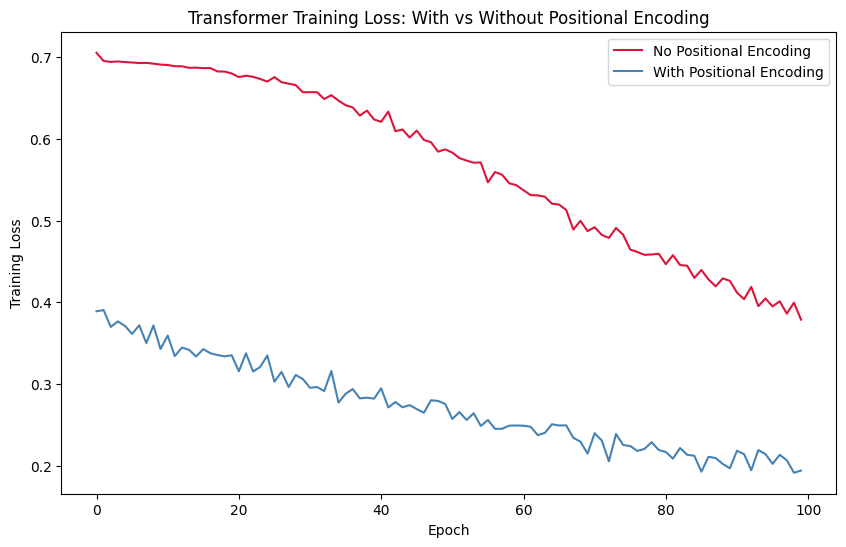

In [116]:
plt.figure(figsize=(10,6))
plt.plot(epoch_losses_no_pe, label='No Positional Encoding', color='crimson')
plt.plot(epoch_losses_with_pe, label='With Positional Encoding', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Transformer Training Loss: With vs Without Positional Encoding')
plt.legend()
plt.show()

In [117]:
split = int(0.8 * len(x))
test_start_idx = split + lookback
test_end_idx = split + lookback + len(x_test) - 1
print(test_start_idx, test_end_idx)
print(jpmc_clean.index[test_start_idx], jpmc_clean.index[test_end_idx])

3005 3751
2022-01-10 00:00:00 2024-12-30 00:00:00


In [118]:
test_dates = jpmc_clean.index[test_start_idx : test_end_idx + 1]
actual_prices = jpmc['Close']['JPM'].values[test_start_idx : test_end_idx + 1]
predicted_class = y_pred_test_class.numpy().flatten()  # convert tensor to flat numpy array
actual_class = y_test_t.numpy().flatten()
correct = (predicted_class == actual_class)

In [119]:
print(len(test_dates))
print(len(actual_prices))
print(len(predicted_class))
print(len(correct))

747
747
747
747


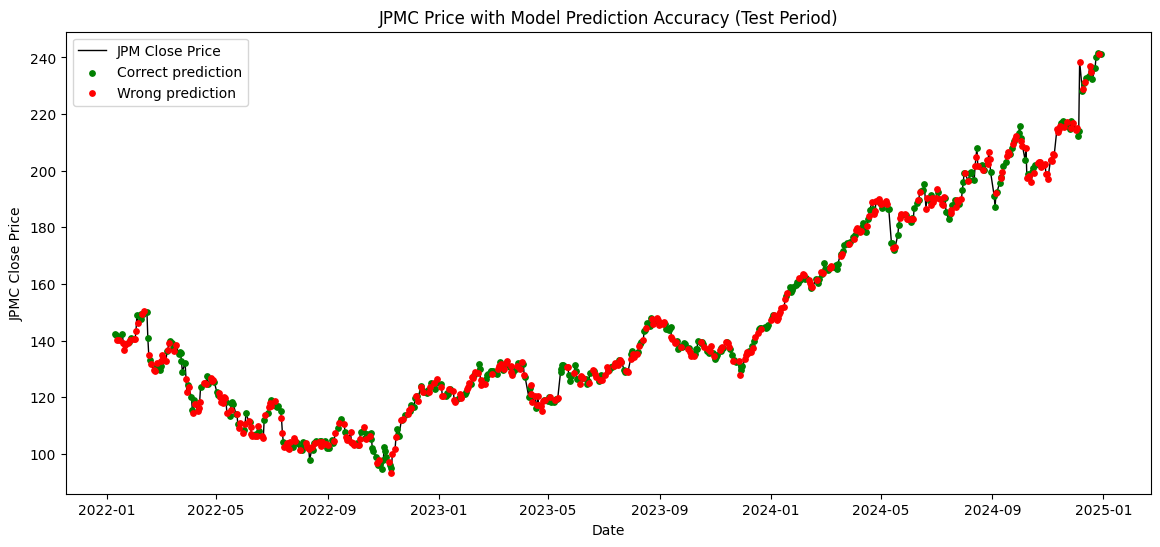

In [120]:
plt.figure(figsize=(14,6))
plt.plot(test_dates, actual_prices, color='black', linewidth=1, label='JPM Close Price')

correct_dates = test_dates[correct]
correct_prices = actual_prices[correct]
wrong_dates = test_dates[~correct]
wrong_prices = actual_prices[~correct]

plt.scatter(correct_dates, correct_prices, color='green', s=15, label='Correct prediction', zorder=5)
plt.scatter(wrong_dates, wrong_prices, color='red', s=15, label='Wrong prediction', zorder=5)

plt.xlabel('Date')
plt.ylabel('JPMC Close Price')
plt.title('JPMC Price with Model Prediction Accuracy (Test Period)')
plt.legend()
plt.show()

In [121]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(actual_class, predicted_class)
print(cm)

[[144 202]
 [169 232]]


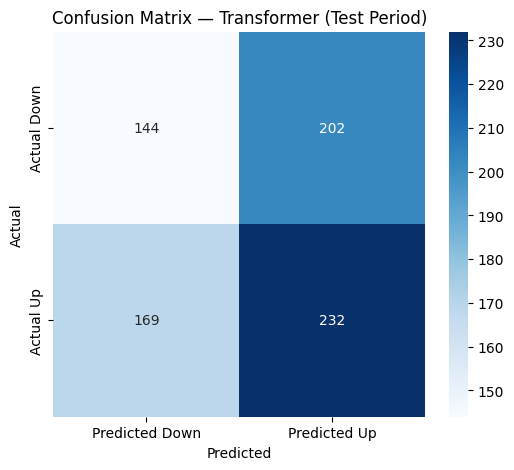

In [122]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title('Confusion Matrix — Transformer (Test Period)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()